<a href="https://colab.research.google.com/github/haniamahrouse/Eye-Disease-Classification/blob/main/eye_disease_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os
import zipfile
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold

In [10]:
import subprocess
print(subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv"],
                     capture_output=True, text=True).stdout)

name, memory.total [MiB]
Tesla T4, 15360 MiB



In [11]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
ZIP_PATH = "/content/drive/MyDrive/Colab Notebooks/EyeDiseaseDataset.zip"
EXTRACT_DIR = "/content/eye_data"        # the zip will be extracted here
OUT_DIR = "outputs"                      # plots and results are saved here

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_SCRATCH = 25
EPOCHS_VGG = 10

os.makedirs(OUT_DIR, exist_ok=True)
torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cpu":
    print("WARNING: no GPU found. Go to Runtime -> Change runtime type -> T4 GPU, then run again.")

torch.backends.cudnn.benchmark = True

device: cuda


In [13]:
if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)

data_root = ""
for root, dirs, files in os.walk(EXTRACT_DIR):
    if "metadata.csv" in files:
        data_root = root
        break
print("data folder:", data_root)
print(os.listdir(data_root))

data folder: /content/eye_data
['catalog', 'Tasks_and_Classes.md', 'metadata.csv', 'splits', 'images']


In [14]:
# find the path of every image
image_paths = {}
for root, dirs, files in os.walk(os.path.join(data_root, "images")):
    for f in files:
        image_paths[f] = os.path.join(root, f)


meta = pd.read_csv(os.path.join(data_root, "metadata.csv"))
val_names = pd.read_csv(os.path.join(data_root, "splits", "val.csv"))["filename"]

df = meta.copy()
df["path"] = df["filename"].map(image_paths)
df = df.rename(columns={"unified_label": "label"})
print("total images:", len(df))
print("images not found:", df["path"].isnull().sum())

df["split"] = "train"
df.loc[df["filename"].isin(val_names), "split"] = "val"
print("val images:", (df["split"] == "val").sum())


def get_group(filename):
    if filename.startswith("ODIR_"):
        return filename.split("_")[1]
    return filename

df["group"] = df["filename"].apply(get_group)

rest = df[df["split"] != "val"]
splitter = StratifiedGroupKFold(n_splits=9, shuffle=True, random_state=42)
for fold_number, (train_part, test_part) in enumerate(splitter.split(rest, rest["label"], rest["group"])):
    df.loc[rest.index[test_part], "split"] = "test"
    break


class_names = sorted(df["label"].unique())
label_to_id = {name: i for i, name in enumerate(class_names)}
df["y"] = df["label"].map(label_to_id)
NUM_CLASSES = len(class_names)
print(class_names)

total images: 11839
images not found: 0
val images: 1197
['AMD', 'Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Hypertension', 'Myopia', 'Normal', 'Others']


In [15]:
# images per class in each split
table = pd.crosstab(df["label"], df["split"])[["train", "val", "test"]]
table["total"] = table.sum(axis=1)
print(table)

split                 train  val  test  total
label                                        
AMD                     210   28    36    274
Cataract                275   34    31    340
Diabetic Retinopathy   3276  426   411   4113
Glaucoma                746   93    91    930
Hypertension             73    9     6     88
Myopia                  235   30    29    294
Normal                 3770  467   461   4698
Others                  875  110   117   1102


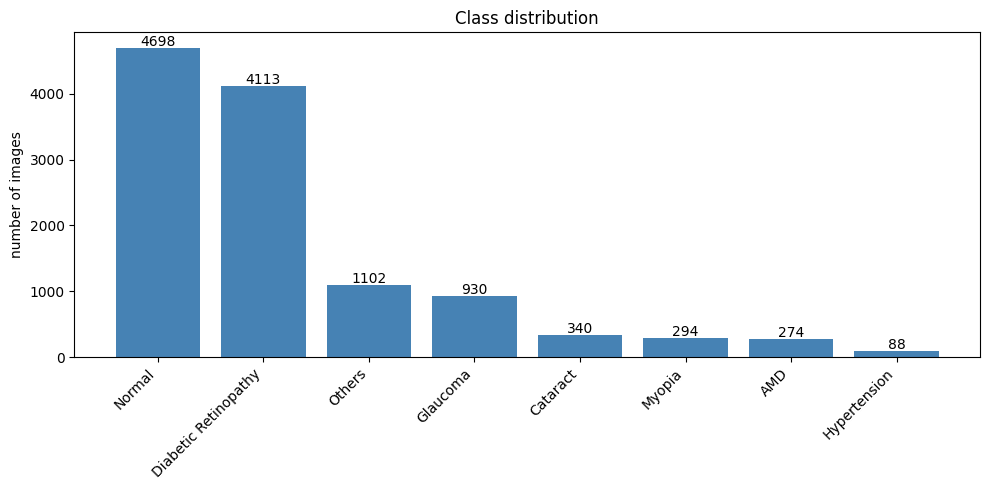

In [16]:
# class distribution plot
counts = df["label"].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(counts.index, counts.values, color="steelblue")
for bar, c in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, c + 30, str(c), ha="center")
plt.xticks(rotation=45, ha="right")
plt.ylabel("number of images")
plt.title("Class distribution")
plt.tight_layout()
plt.savefig(OUT_DIR + "/class_distribution.png")
plt.show()

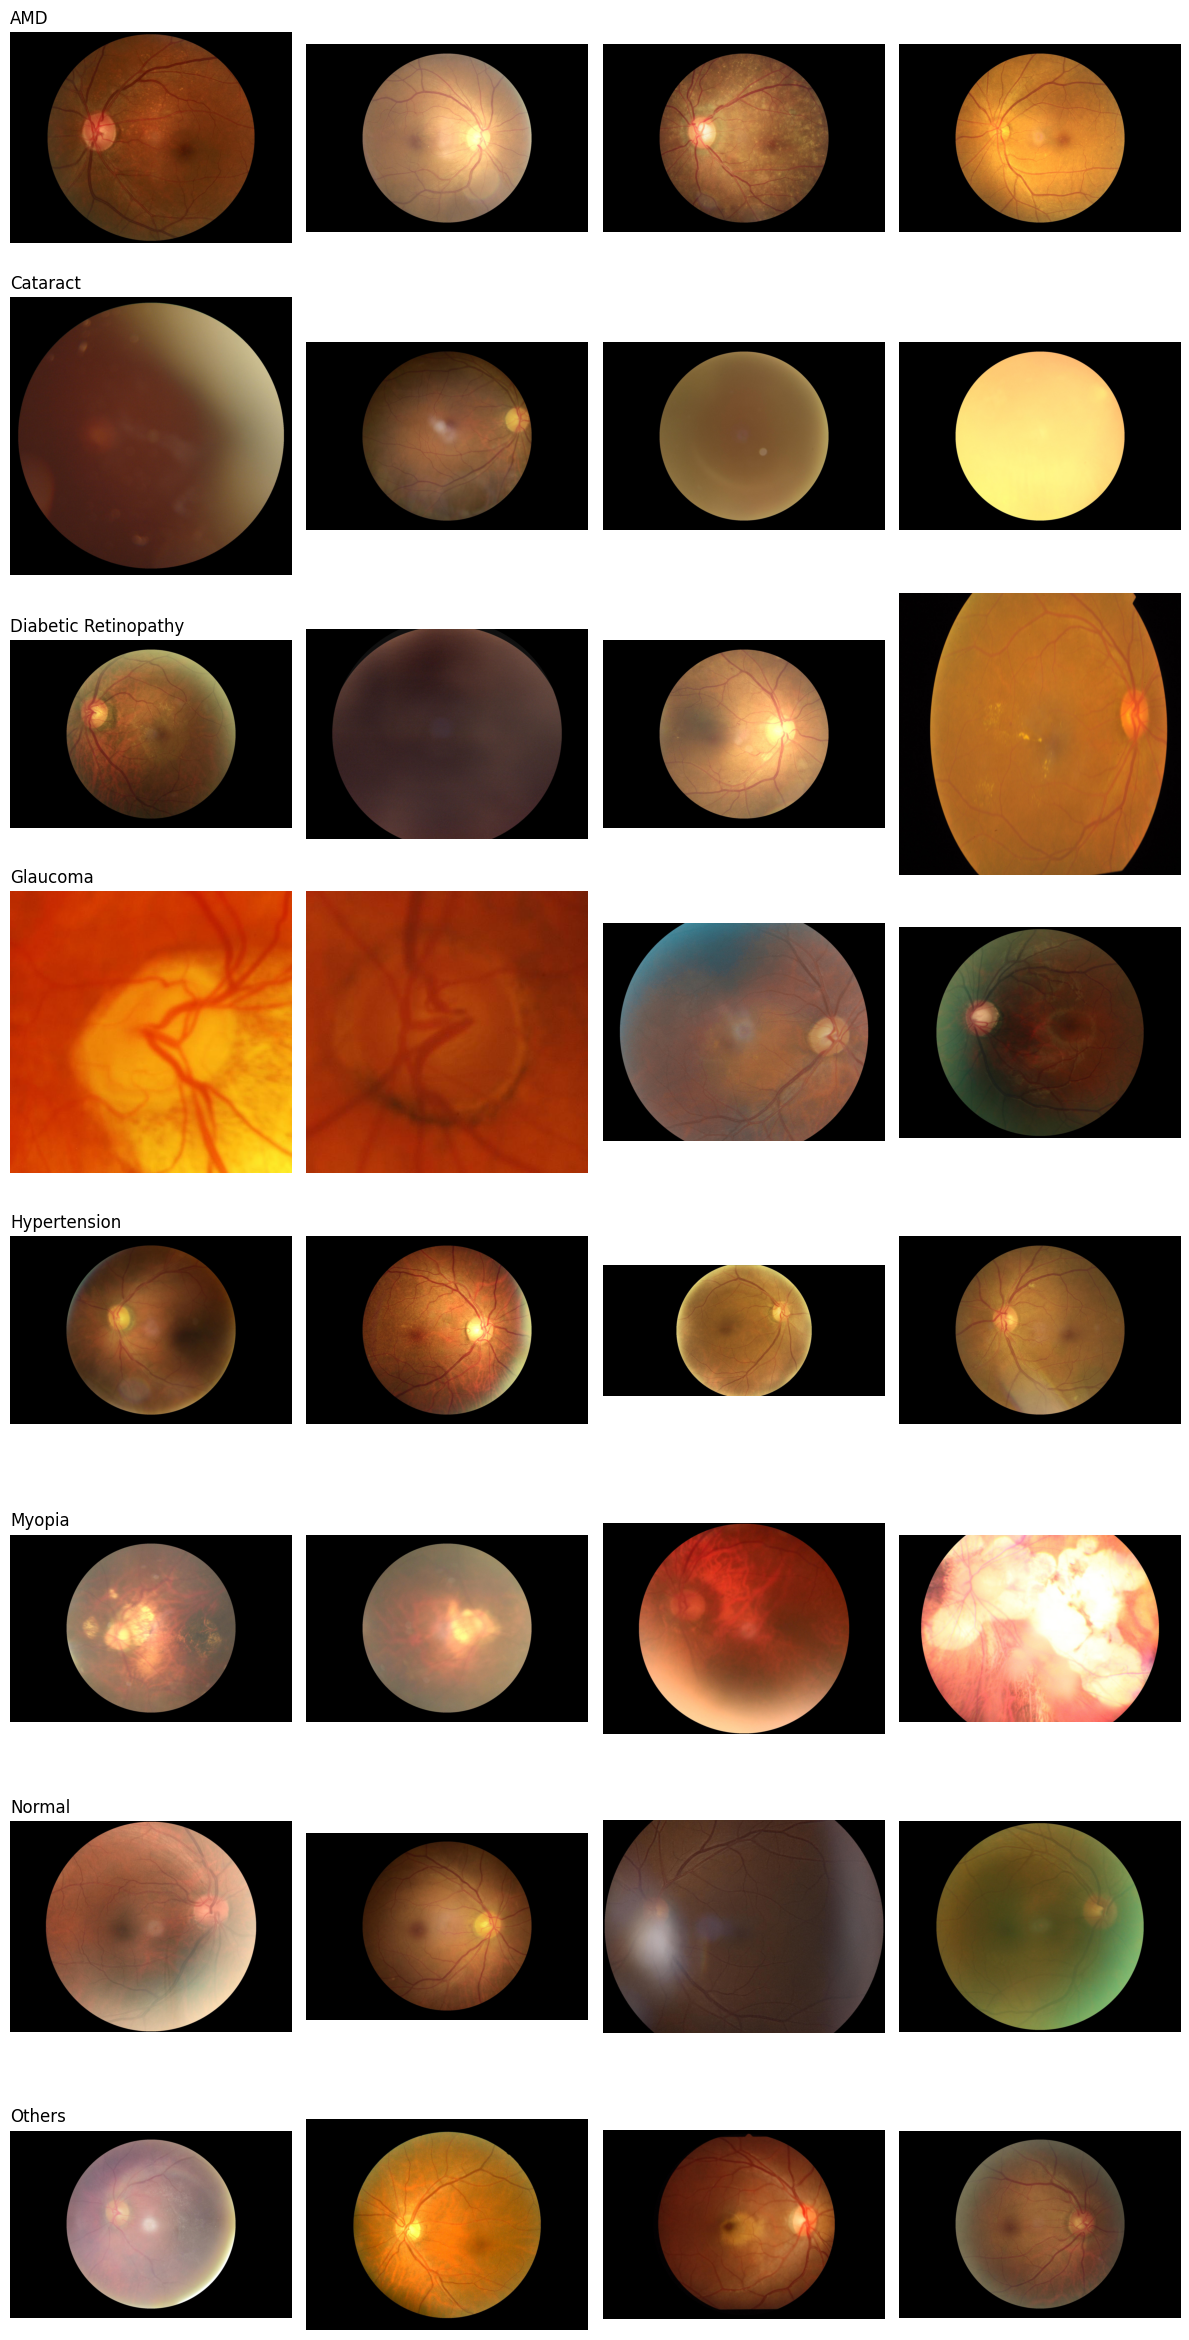

In [17]:
# 4 sample images from each class
plt.figure(figsize=(12, 24))
n = 1
for name in class_names:
    samples = df[df["label"] == name].sample(min(4, (df["label"] == name).sum()), random_state=1)
    for path in samples["path"]:
        plt.subplot(NUM_CLASSES, 4, n)
        plt.imshow(Image.open(path).convert("RGB"))
        plt.axis("off")
        if n % 4 == 1:
            plt.title(name, loc="left")
        n += 1
plt.tight_layout()
plt.savefig(OUT_DIR + "/sample_images.png")
plt.show()

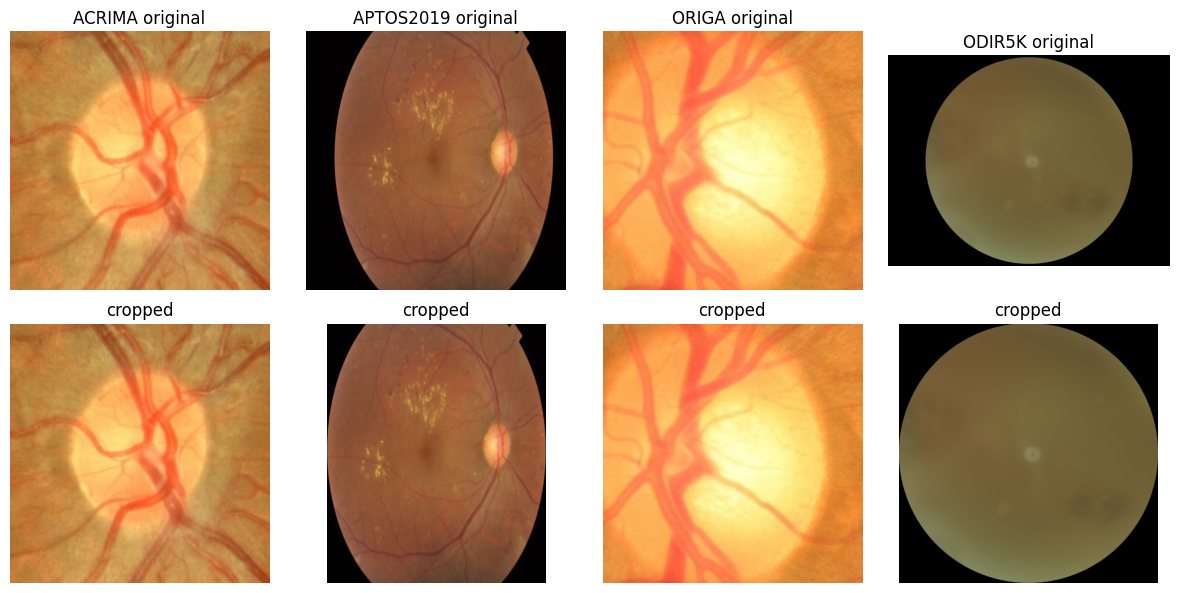

In [18]:
def crop_black_border(img):
    # img is a numpy array (height, width, 3)
    gray = img.mean(axis=2)
    mask = gray > 15                      # pixels that are not black
    if mask.sum() == 0:
        return img
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    return img[rows[0]:rows[-1] + 1, cols[0]:cols[-1] + 1]

# show the difference on one image from each source
plt.figure(figsize=(12, 6))
sources = df["dataset"].unique()
for i, source in enumerate(sources):
    path = df[df["dataset"] == source]["path"].iloc[0]
    img = np.array(Image.open(path).convert("RGB"))
    cropped = crop_black_border(img)
    plt.subplot(2, len(sources), i + 1)
    plt.imshow(img)
    plt.title(source + " original")
    plt.axis("off")
    plt.subplot(2, len(sources), i + 1 + len(sources))
    plt.imshow(cropped)
    plt.title("cropped")
    plt.axis("off")
plt.tight_layout()
plt.savefig(OUT_DIR + "/black_border.png")
plt.show()

In [19]:
images_raw = []      # with black border
images_crop = []     # border cropped

for path in tqdm(df["path"]):
    img = Image.open(path).convert("RGB")
    images_raw.append(img.resize((IMG_SIZE, IMG_SIZE)))

    cropped = crop_black_border(np.array(img))
    images_crop.append(Image.fromarray(cropped).resize((IMG_SIZE, IMG_SIZE)))

labels = df["y"].values
train_idx = np.where(df["split"] == "train")[0]
val_idx = np.where(df["split"] == "val")[0]
test_idx = np.where(df["split"] == "test")[0]
print(len(train_idx), len(val_idx), len(test_idx))

100%|██████████| 11839/11839 [44:59<00:00,  4.39it/s]

9460 1197 1182


In [20]:
train_counts = np.bincount(labels[train_idx], minlength=NUM_CLASSES)
weights = len(train_idx) / (NUM_CLASSES * train_counts)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

for name, c, w in zip(class_names, train_counts, weights):
    print(name, "| train images:", c, "| weight:", round(w, 2))

AMD | train images: 210 | weight: 5.63
Cataract | train images: 275 | weight: 4.3
Diabetic Retinopathy | train images: 3276 | weight: 0.36
Glaucoma | train images: 746 | weight: 1.59
Hypertension | train images: 73 | weight: 16.2
Myopia | train images: 235 | weight: 5.03
Normal | train images: 3770 | weight: 0.31
Others | train images: 875 | weight: 1.35


In [21]:
mean = [0.485, 0.456, 0.406]     # ImageNet mean and std (VGG was trained with these)
std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

class EyeDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        return self.transform(self.images[i]), self.labels[i]

def make_loaders(images):
    train_ds = EyeDataset([images[i] for i in train_idx], labels[train_idx].tolist(), train_transform)
    val_ds = EyeDataset([images[i] for i in val_idx], labels[val_idx].tolist(), test_transform)
    test_ds = EyeDataset([images[i] for i in test_idx], labels[test_idx].tolist(), test_transform)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader

In [22]:
def predict(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, y in loader:
            outputs = model(images.to(device))
            probs = torch.softmax(outputs, dim=1)      # softmax -> probabilities
            all_preds += probs.argmax(dim=1).cpu().tolist()
            all_labels += y.tolist()
    return np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, val_loader, epochs, lr, name):
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)          # weighted loss
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    train_losses = []
    val_f1s = []
    best_f1 = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, y in train_loader:
            images = images.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        preds, true = predict(model, val_loader)
        val_f1 = f1_score(true, preds, average="macro")
        val_acc = (preds == true).mean()

        train_losses.append(train_loss)
        val_f1s.append(val_f1)
        print("epoch", epoch + 1, "/", epochs, "| train loss:", round(train_loss, 3),
              "| val acc:", round(val_acc, 3), "| val macro F1:", round(val_f1, 3))

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), name + ".pth")

    model.load_state_dict(torch.load(name + ".pth"))
    return model, train_losses, val_f1s, best_f1


def show_report(model, test_loader, name):
    preds, true = predict(model, test_loader)
    print("=== " + name + " (test set) ===")
    print(classification_report(true, preds, target_names=class_names, digits=3))
    report = classification_report(true, preds, target_names=class_names, output_dict=True)
    return report, preds, true

In [23]:
class ScratchCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, NUM_CLASSES),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x


##### scratch_with_border
epoch 1 / 25 | train loss: 1.904 | val acc: 0.317 | val macro F1: 0.223
epoch 2 / 25 | train loss: 1.792 | val acc: 0.258 | val macro F1: 0.142
epoch 3 / 25 | train loss: 1.76 | val acc: 0.233 | val macro F1: 0.175
epoch 4 / 25 | train loss: 1.754 | val acc: 0.346 | val macro F1: 0.245
epoch 5 / 25 | train loss: 1.704 | val acc: 0.327 | val macro F1: 0.231
epoch 6 / 25 | train loss: 1.715 | val acc: 0.328 | val macro F1: 0.199
epoch 7 / 25 | train loss: 1.703 | val acc: 0.325 | val macro F1: 0.255
epoch 8 / 25 | train loss: 1.686 | val acc: 0.333 | val macro F1: 0.246
epoch 9 / 25 | train loss: 1.656 | val acc: 0.376 | val macro F1: 0.262
epoch 10 / 25 | train loss: 1.63 | val acc: 0.347 | val macro F1: 0.259
epoch 11 / 25 | train loss: 1.61 | val acc: 0.409 | val macro F1: 0.312
epoch 12 / 25 | train loss: 1.581 | val acc: 0.377 | val macro F1: 0.264
epoch 13 / 25 | train loss: 1.559 | val acc: 0.368 | val macro F1: 0.283
epoch 14 / 25 | train loss: 1.557 | 

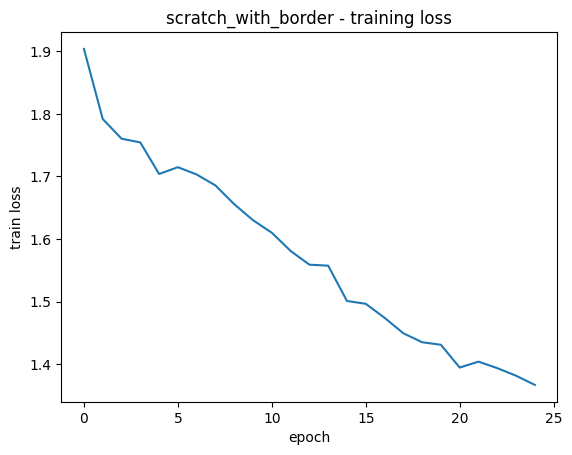

=== scratch_with_border (test set) ===
                      precision    recall  f1-score   support

                 AMD      0.500     0.028     0.053        36
            Cataract      0.333     0.903     0.487        31
Diabetic Retinopathy      0.905     0.443     0.595       411
            Glaucoma      0.401     0.626     0.489        91
        Hypertension      0.000     0.000     0.000         6
              Myopia      0.308     0.690     0.426        29
              Normal      0.753     0.284     0.413       461
              Others      0.185     0.795     0.300       117

            accuracy                          0.433      1182
           macro avg      0.423     0.471     0.345      1182
        weighted avg      0.689     0.433     0.460      1182


##### scratch_cropped
epoch 1 / 25 | train loss: 1.94 | val acc: 0.261 | val macro F1: 0.197
epoch 2 / 25 | train loss: 1.825 | val acc: 0.16 | val macro F1: 0.144
epoch 3 / 25 | train loss: 1.764 | val acc: 0.243

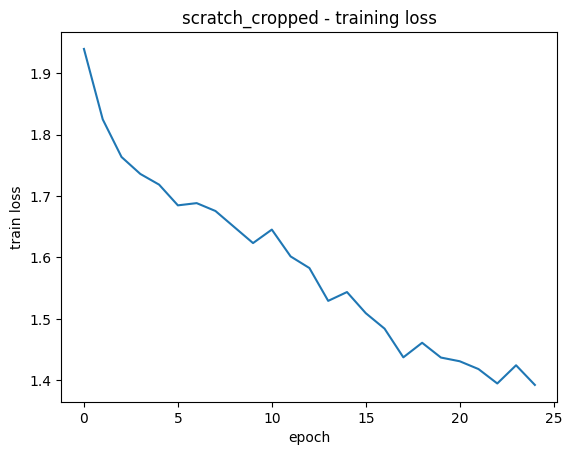

=== scratch_cropped (test set) ===
                      precision    recall  f1-score   support

                 AMD      0.112     0.278     0.160        36
            Cataract      0.241     0.871     0.378        31
Diabetic Retinopathy      0.916     0.423     0.579       411
            Glaucoma      0.457     0.692     0.550        91
        Hypertension      0.000     0.000     0.000         6
              Myopia      0.301     0.759     0.431        29
              Normal      0.672     0.364     0.473       461
              Others      0.224     0.256     0.239       117

            accuracy                          0.418      1182
           macro avg      0.365     0.455     0.351      1182
        weighted avg      0.655     0.418     0.477      1182



In [24]:
results = {}

for use_crop in [False, True]:
    if use_crop:
        name = "scratch_cropped"
        images = images_crop
    else:
        name = "scratch_with_border"
        images = images_raw
    print("\n#####", name)

    train_loader, val_loader, test_loader = make_loaders(images)
    model = ScratchCNN()
    model, train_losses, val_f1s, best_f1 = train_model(model, train_loader, val_loader,
                                                        EPOCHS_SCRATCH, 0.001, name)

    # loss curve
    plt.plot(train_losses)
    plt.xlabel("epoch")
    plt.ylabel("train loss")
    plt.title(name + " - training loss")
    plt.savefig(OUT_DIR + "/" + name + "_loss.png")
    plt.show()

    report, preds, true = show_report(model, test_loader, name)
    results[use_crop] = [model, report, preds, true, best_f1]

In [25]:
border_table = pd.DataFrame({
    "input": ["with border", "border cropped"],
    "best val macro F1": [results[False][4], results[True][4]],
    "test accuracy": [results[False][1]["accuracy"], results[True][1]["accuracy"]],
    "test macro F1": [results[False][1]["macro avg"]["f1-score"], results[True][1]["macro avg"]["f1-score"]],
})
print(border_table.round(3))
border_table.to_csv(OUT_DIR + "/border_experiment.csv", index=False)

# use the better version from now on
best_crop = results[True][4] > results[False][4]
print("better version:", "cropped" if best_crop else "with border")

scratch_model, scratch_report, scratch_preds, test_labels, _ = results[best_crop]
if best_crop:
    best_images = images_crop
else:
    best_images = images_raw

            input  best val macro F1  test accuracy  test macro F1
0     with border              0.368          0.433          0.345
1  border cropped              0.360          0.418          0.351
better version: with border


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:10<00:00, 54.2MB/s]


epoch 1 / 10 | train loss: 1.506 | val acc: 0.475 | val macro F1: 0.317
epoch 2 / 10 | train loss: 1.316 | val acc: 0.393 | val macro F1: 0.347
epoch 3 / 10 | train loss: 1.212 | val acc: 0.489 | val macro F1: 0.409
epoch 4 / 10 | train loss: 1.135 | val acc: 0.476 | val macro F1: 0.459
epoch 5 / 10 | train loss: 1.06 | val acc: 0.474 | val macro F1: 0.429
epoch 6 / 10 | train loss: 1.042 | val acc: 0.495 | val macro F1: 0.46
epoch 7 / 10 | train loss: 0.973 | val acc: 0.524 | val macro F1: 0.514
epoch 8 / 10 | train loss: 0.968 | val acc: 0.5 | val macro F1: 0.484
epoch 9 / 10 | train loss: 0.914 | val acc: 0.522 | val macro F1: 0.473
epoch 10 / 10 | train loss: 0.887 | val acc: 0.513 | val macro F1: 0.46


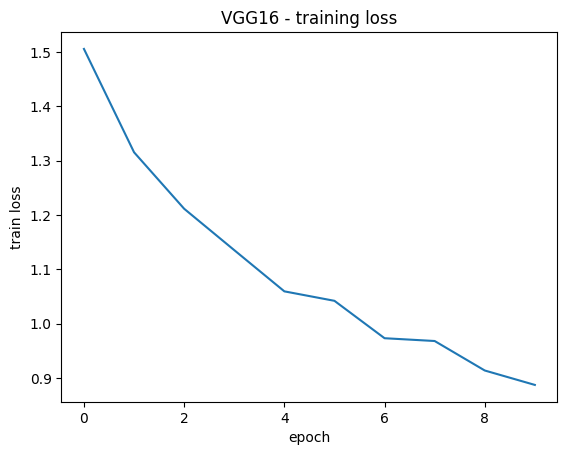

=== VGG16 (test set) ===
                      precision    recall  f1-score   support

                 AMD      0.477     0.583     0.525        36
            Cataract      0.590     0.742     0.657        31
Diabetic Retinopathy      0.945     0.499     0.653       411
            Glaucoma      0.455     0.714     0.556        91
        Hypertension      0.000     0.000     0.000         6
              Myopia      0.870     0.690     0.769        29
              Normal      0.855     0.410     0.554       461
              Others      0.191     0.795     0.308       117

            accuracy                          0.521      1182
           macro avg      0.548     0.554     0.503      1182
        weighted avg      0.767     0.521     0.569      1182



In [26]:
vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

for param in vgg.features[:17].parameters():
    param.requires_grad = False

# new last layer
vgg.classifier[6] = nn.Linear(4096, NUM_CLASSES)

train_loader, val_loader, test_loader = make_loaders(best_images)
vgg, vgg_losses, vgg_f1s, vgg_best_f1 = train_model(vgg, train_loader, val_loader,
                                                    EPOCHS_VGG, 0.0001, "vgg16")

plt.plot(vgg_losses)
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.title("VGG16 - training loss")
plt.savefig(OUT_DIR + "/vgg16_loss.png")
plt.show()

vgg_report, vgg_preds, _ = show_report(vgg, test_loader, "VGG16")

In [27]:
rows = []
for name in class_names:
    rows.append([name,
                 scratch_report[name]["precision"], scratch_report[name]["recall"], scratch_report[name]["f1-score"],
                 vgg_report[name]["precision"], vgg_report[name]["recall"], vgg_report[name]["f1-score"]])

per_class = pd.DataFrame(rows, columns=["class", "scratch precision", "scratch recall", "scratch F1",
                                        "vgg precision", "vgg recall", "vgg F1"])
print(per_class.round(3))
per_class.to_csv(OUT_DIR + "/per_class_comparison.csv", index=False)

                  class  scratch precision  scratch recall  scratch F1  \
0                   AMD              0.500           0.028       0.053   
1              Cataract              0.333           0.903       0.487   
2  Diabetic Retinopathy              0.905           0.443       0.595   
3              Glaucoma              0.401           0.626       0.489   
4          Hypertension              0.000           0.000       0.000   
5                Myopia              0.308           0.690       0.426   
6                Normal              0.753           0.284       0.413   
7                Others              0.185           0.795       0.300   

   vgg precision  vgg recall  vgg F1  
0          0.477       0.583   0.525  
1          0.590       0.742   0.657  
2          0.945       0.499   0.653  
3          0.455       0.714   0.556  
4          0.000       0.000   0.000  
5          0.870       0.690   0.769  
6          0.855       0.410   0.554  
7          0.191     

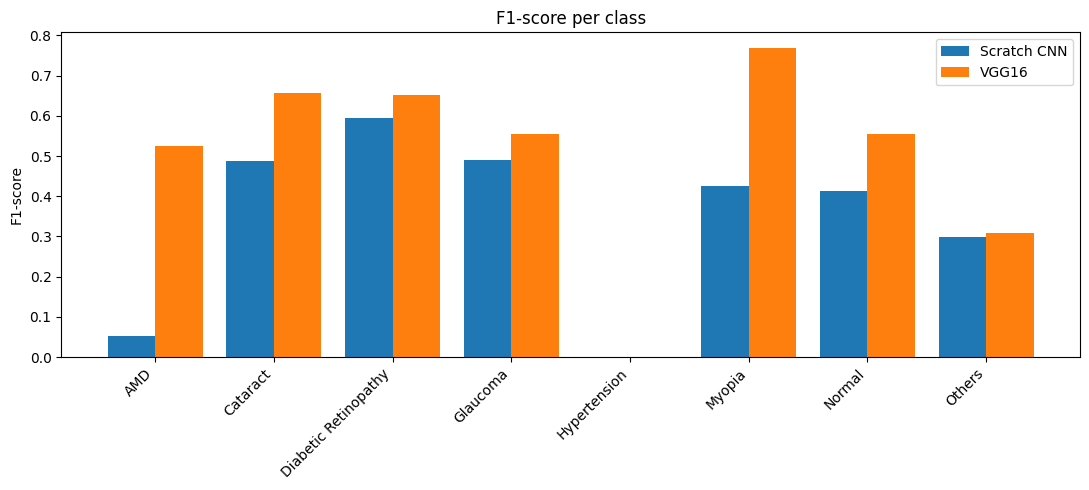

In [28]:
# F1 per class
x = np.arange(NUM_CLASSES)
plt.figure(figsize=(11, 5))
plt.bar(x - 0.2, per_class["scratch F1"], width=0.4, label="Scratch CNN")
plt.bar(x + 0.2, per_class["vgg F1"], width=0.4, label="VGG16")
plt.xticks(x, class_names, rotation=45, ha="right")
plt.ylabel("F1-score")
plt.title("F1-score per class")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + "/f1_per_class.png")
plt.show()

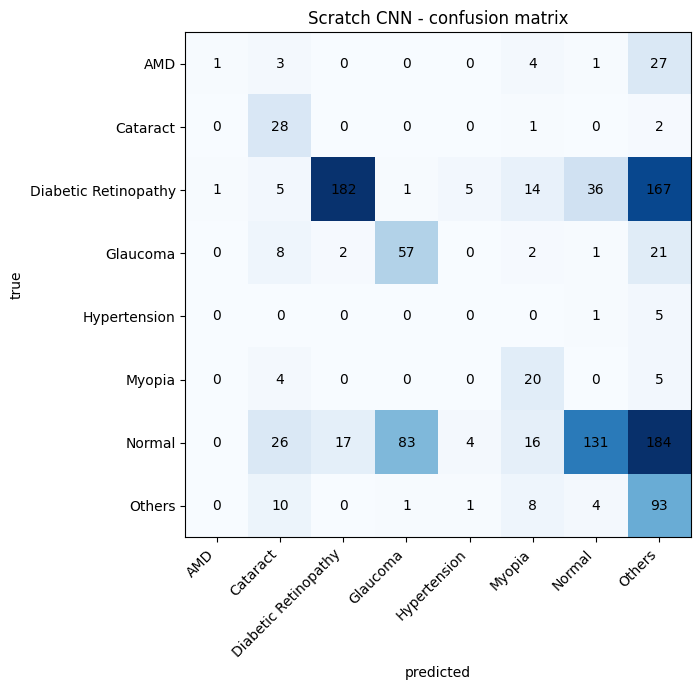

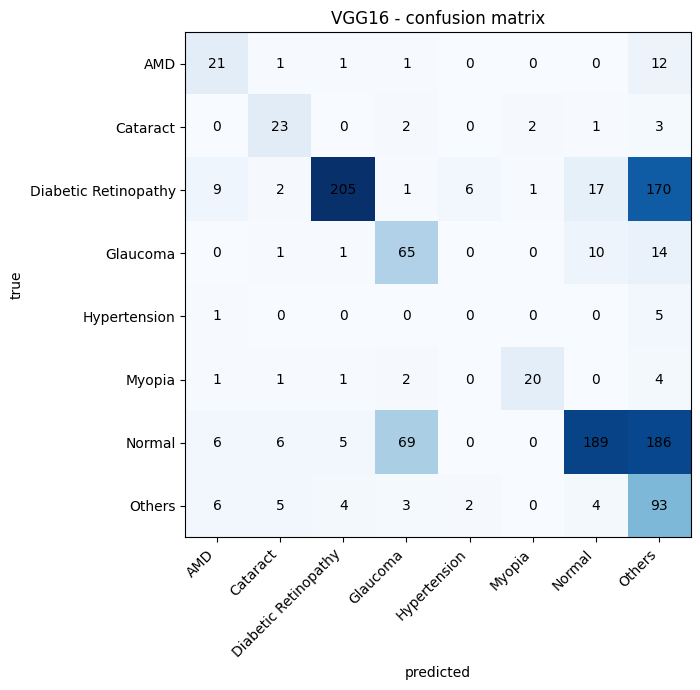

In [29]:
# confusion matrices
for model_name, preds in [("Scratch CNN", scratch_preds), ("VGG16", vgg_preds)]:
    cm = confusion_matrix(test_labels, preds)
    plt.figure(figsize=(8, 7))
    plt.imshow(cm, cmap="Blues")
    plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha="right")
    plt.yticks(range(NUM_CLASSES), class_names)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xlabel("predicted")
    plt.ylabel("true")
    plt.title(model_name + " - confusion matrix")
    plt.tight_layout()
    plt.savefig(OUT_DIR + "/confusion_" + model_name.split()[0] + ".png")
    plt.show()

In [30]:
# overall numbers + speed
def time_per_image(model, loader):
    start = time.time()
    predict(model, loader)
    return (time.time() - start) / len(loader.dataset) * 1000     # ms per image

summary = pd.DataFrame({
    "model": ["Scratch CNN", "VGG16"],
    "accuracy": [scratch_report["accuracy"], vgg_report["accuracy"]],
    "macro precision": [scratch_report["macro avg"]["precision"], vgg_report["macro avg"]["precision"]],
    "macro recall": [scratch_report["macro avg"]["recall"], vgg_report["macro avg"]["recall"]],
    "macro F1": [scratch_report["macro avg"]["f1-score"], vgg_report["macro avg"]["f1-score"]],
    "parameters (millions)": [sum(p.numel() for p in scratch_model.parameters()) / 1e6,
                              sum(p.numel() for p in vgg.parameters()) / 1e6],
    "ms per image": [time_per_image(scratch_model, test_loader), time_per_image(vgg, test_loader)],
})
print(summary.round(3))
summary.to_csv(OUT_DIR + "/summary_comparison.csv", index=False)

         model  accuracy  macro precision  macro recall  macro F1  \
0  Scratch CNN     0.433            0.423         0.471     0.345   
1        VGG16     0.521            0.548         0.554     0.503   

   parameters (millions)  ms per image  
0                  1.014         2.356  
1                134.293         5.631  
